# Лабораторная работа №1: Первичное исследование данных

## 1. Постановка задачи

### Описание датасета
Датасет "Wind & Solar Energy Production Dataset" представляет собой детализированный почасовой учёт производства электроэнергии из возобновляемых источников (ветра и солнца) во Франции за период с 1 января 2020 года по 30 ноября 2025 года. Набор данных состоит из 51 864 полных записей и включает 9 признаков.
Данные содержат:
Временные признаки: дата, час, день года, название дня недели, месяц, сезон.
Признаки генерации: источник энергии (Ветер, Солнце, Смешанный) и общий объём производства в МВт*ч за час.

### Условный заказчик
Данные могут быть использованы широким кругом стейкхолдеров в энергетической отрасли и за её пределами:
Операторы энергосистем: Для балансировки нагрузки, планирования ремонтов и анализа работы энергосети.
Компании-производители возобновляемой энергии: Для оценки эффективности своих активов, планирования выручки и бенчмаркинга.
Аналитические и консалтинговые агентства: Для исследования рынка, построения прогнозов и подготовки отчетов для инвесторов.
Государственные регуляторы и экологические организации: Для мониторинга прогресса в достижении целей по энергопереходу и анализа воздействия ВИЭ на экологию.
Учебные и научные учреждения: Для проведения прикладных исследований в области data science, машинного обучения и анализа временных рядов.

### Возможные задачи ИАД
1. Анализ временных закономерностей: Выявление и визуализация циклических паттернов — суточных (дневные/ночные пики солнечной генерации), недельных (рабочие/выходные дни) и сезонных (зима/лето) колебаний в производстве энергии по источникам.
2. Сравнительный анализ источников генерации: Исследование вклада ветровой и солнечной энергии в общую выработку за разные периоды. Анализ стабильности каждого источника, вычисление их коэффициентов использования мощности в разрезе времени.
3. Классификация: Построение модели для предсказания типа преобладающего источника энергии (Ветер/Солнце/Смешанный) на основе временных признаков (час, месяц, сезон).

## 2. Паспорт датасета

### Загрузка данных


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/Energy Production Dataset.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 51864 строк, 9 столбцов


,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,11/30/2025,21,22,Wind,334,Sunday,November,Fall,5281
1,11/30/2025,18,19,Wind,334,Sunday,November,Fall,3824
2,11/30/2025,16,17,Wind,334,Sunday,November,Fall,3824
3,11/30/2025,23,0,Wind,334,Sunday,November,Fall,6120
4,11/30/2025,6,7,Wind,334,Sunday,November,Fall,4387


### Структура данных

In [43]:
# Информация о столбцах и типах
df.info()

# Статистика по числовым признакам
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 51864 entries, 0 to 51863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         51864 non-null  str  
 1   Start_Hour   51864 non-null  int64
 2   End_Hour     51864 non-null  int64
 3   Source       51864 non-null  str  
 4   Day_of_Year  51864 non-null  int64
 5   Day_Name     51864 non-null  str  
 6   Month_Name   51864 non-null  str  
 7   Season       51864 non-null  str  
 8   Production   51864 non-null  int64
dtypes: int64(4), str(5)
memory usage: 3.6 MB


,Start_Hour,End_Hour,Day_of_Year,Production
count,51864.000000,51864.000000,51864.000000,51864.000000
mean,11.500000,11.500000,180.798415,6215.069933
std,6.922253,6.922253,104.291387,3978.364965
min,0.000000,0.000000,1.000000,58.000000
25%,5.750000,5.750000,91.000000,3111.000000
50%,11.500000,11.500000,181.000000,5372.000000
75%,17.250000,17.250000,271.000000,8501.000000
max,23.000000,23.000000,366.000000,23446.000000


## 3. Аудит качества данных

### 3.1. Пропуски

In [44]:
# Пропуски по столбцам
missing = pd.DataFrame({
    'Пропуски': df.isnull().sum(),
    'Доля (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Пропуски', ascending=False)

missing[missing['Пропуски'] > 0]

,Пропуски,Доля (%)


### 3.2. Дубликаты

In [45]:
duplicates = df.duplicated().sum()
print(f'Полных дубликатов строк: {duplicates}')

Полных дубликатов строк: 0


### 3.3. Выбросы

Выбросов по методу IQR: 951


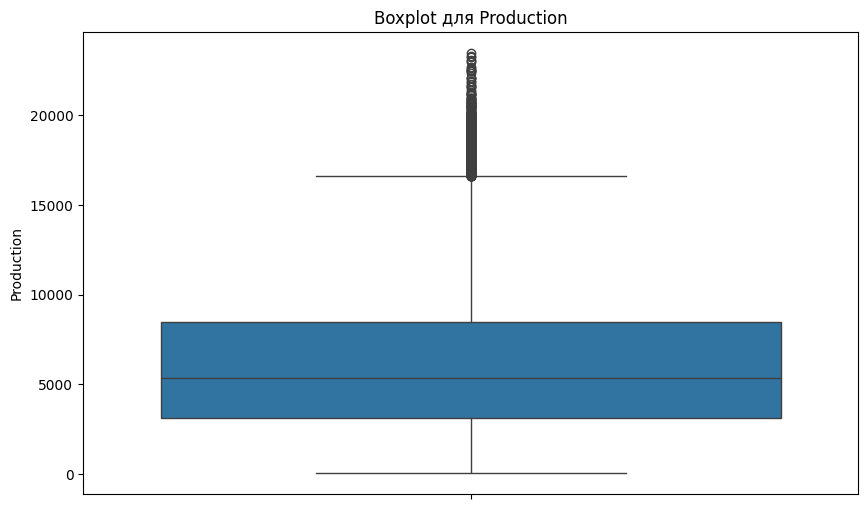

In [46]:
column = 'Production'
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f'Выбросов по методу IQR: {len(outliers)}')

# Визуализация
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y=column)
plt.title(f'Boxplot для {column}')
plt.show()

## 4. Разведочный анализ (EDA)

### 4.1. Распределение числового признака

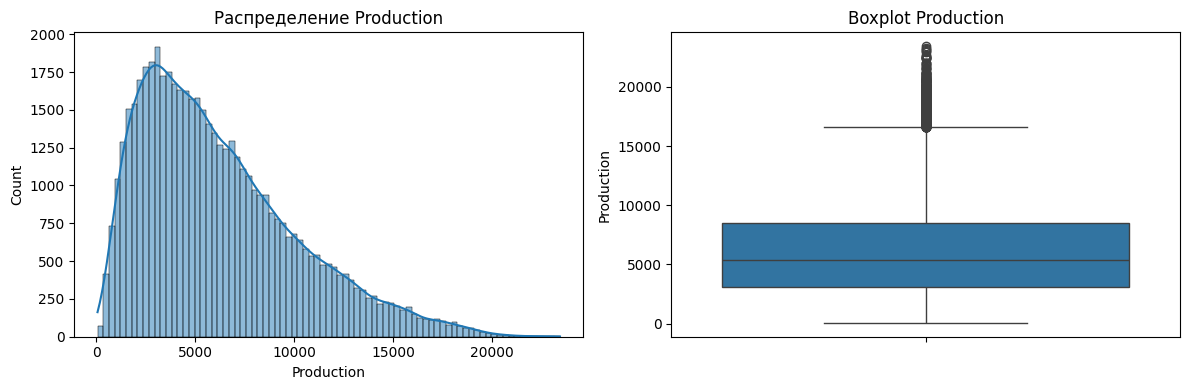

In [47]:
numeric_col = 'Production'

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df[numeric_col], kde=True)
plt.title(f'Распределение {numeric_col}')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[numeric_col])
plt.title(f'Boxplot {numeric_col}')
plt.tight_layout()
plt.show()

### 4.2. Анализ категориального признака

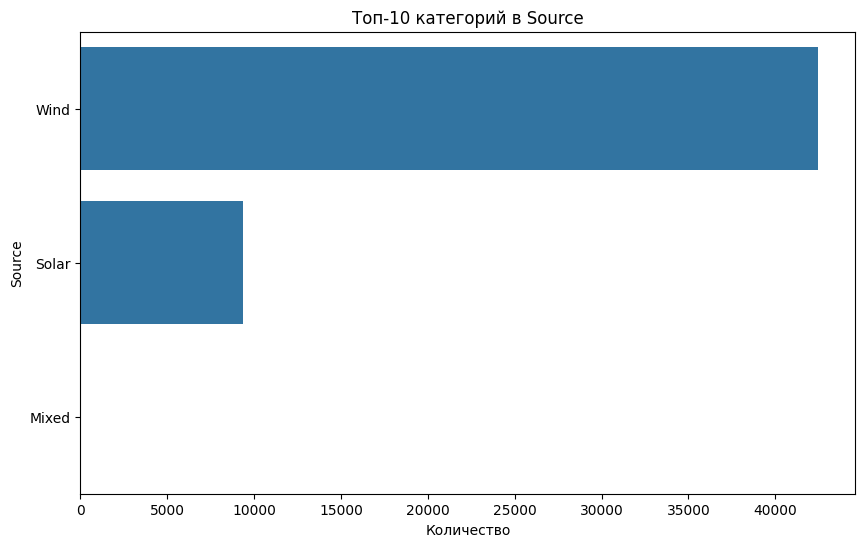

In [48]:
cat_col = 'Source'

plt.figure(figsize=(10, 6))
top_categories = df[cat_col].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title(f'Топ-10 категорий в {cat_col}')
plt.xlabel('Количество')
plt.show()

## 5. Выводы
Детали в файле `report/quality_report.md`